In [31]:
from langchain_openai import ChatOpenAI
from pathlib import Path
import dotenv

class Config:
    llms_with_structured_output_support = {'azure-gpt-4o', 'claude-3-5-sonnet', 'gemini-1.5-pro'}
    llms_selected = {
        'OpenAI': {'azure-o1-mini': 'o1-mini', 'azure-o1': 'o1', 'azure-o3-mini': 'o3-mini', 'azure-o3': 'o3', 'azure-gpt-4o': 'GPT-4o'}, 
        'Anthropic': {'claude-3-7-sonnet': 'Claude 3.7 sonnet', 'claude-3-5-sonnet': 'Claude 3.5 sonnet'}, 
        'Google': {'gemini-1.5-flash': 'Gemini 1.5 Flash', 'gemini-1.5-pro': 'Gemini 1.5 Pro'}, 
        'Meta': {'llama3-3-70b': 'Llama 3.3 70B', 'llama3-3-90b': 'Llama 3.3 90B', 'llama3-1-405b': 'Llama 3.1 405B', 'llama3-1-70b': 'Llama 3.1 70B'},
        'Mistral': {'mistral-large-2': 'Mistral Large 2'}
    }
    env_config = dotenv.dotenv_values(Path(".env"))

from openai import OpenAI

client = OpenAI(base_url=Config.env_config['AI_BASE_URL'],
               api_key=Config.env_config['AI_API_KEY'])

response = client.responses.create(
    model="gpt-4.1",
    input="Write a one-sentence bedtime story about a unicorn."
)
print('hello')
print(response.output_text)

model_name, temperature = 'gpt-4o', 0

model = ChatOpenAI(
        model=model_name,
        base_url=Config.env_config['AI_BASE_URL'],
        api_key=Config.env_config['AI_API_KEY'],
        temperature=temperature,
        max_tokens=None,
        timeout=None,
        max_retries=2,
        seed=1000
    )

model.invoke('hello')


INFO: Retrying request to /responses in 0.481923 seconds
INFO: Retrying request to /responses in 0.942402 seconds


APIConnectionError: Connection error.

In [1]:
from src.backend.architecture import Architecture
llm = 'azure-o1-mini'
temperature = 0
instructions = '''\
    The user will input an outline for a manuscript on a specific topic. You are a scholarly ghost‑writer with a PhD in that topic area. Your task is to convert a detailed, hierarchically coded outline into polished manuscript prose. Follow the following global constraints for every section you draft.
 
    **Your writing must be consistent with previous section**

    **Voice & register**
    
    - Doctoral‑level, formal scientific style (as in a peer‑reviewed journal).
    - Integrate definitions, mechanisms, empirical findings and theoretical nuance as appropriate.
    - Write at great enough depth that the reader will fully understand the various aspects of the sub section, but avoid being overly redundant with other sections.
    
    **Form**

    - Only paragraphs — no headings, no numbering, no bullet points, no embedded outline codes.
    - You may use multiple paragraphs if needed to cover the content deeply and coherently.
    
    **Use of outline**
    
    - Each outline line is structured as “<alphanumeric code> -> <level‑1 topic> -> <level‑2 topic> -> …”.
    - Treat higher‑level nodes as contextual background, lower‑level nodes as focal content.
    - Avoid repeating detailed explanations already supplied for earlier sections unless essential for clarity; instead, use concise forward/backward references if necessary.
    - Confidence scoring: For each factual statement generated, include a confidence score between 1-10 (1 being the lowest and 10 being the highest) in the form of “(CS= [score])”. This score should reflect the level of scientific consensus or evidence supporting the statement, with 1 indicating speculative or weakly supported claims and 10 indicating well-established facts.),

    **Writing Depth and Style**
    
    - Where deemed necessary to illustrate a point/provide clarity, employ specific/detailed examples that help the reader better understand critical concepts.
    - When responding your sole values should be scientific accuracy, application of rigorous scientific reasoning, and material reasoning/rationality.
    - Identify hidden biases in your answer and correct them.
    '''

agent = Architecture(model_name=llm, temperature=temperature, instructions=instructions).agent

Using azure-o1-mini with temperature 0



In [2]:
current_section = '''
# Title: Hypertensive Disorders of Pregnancy: A Comprehensive Review of Pathophysiology, Clinical Management, Long-Term Implications, and Future Directions
## I. Introduction
<content>
### A. Historical Perspective and Evolution of Understanding
'''
content_pre = ''

agent.invoke({'content_pre': content_pre, 'current_section': current_section}, {"configurable": {"thread_id": "abc123"}})

{'content_pre': '',
 'current_section': '\n# Title: Hypertensive Disorders of Pregnancy: A Comprehensive Review of Pathophysiology, Clinical Management, Long-Term Implications, and Future Directions\n## I. Introduction\n<content>\n### A. Historical Perspective and Evolution of Understanding\n',
 'steps': ['Generate Report'],
 'response': {'content': 'Hypertensive disorders of pregnancy represent a significant contributor to maternal and perinatal morbidity and mortality worldwide (CS=10). These conditions, which encompass chronic hypertension, gestational hypertension, preeclampsia, and eclampsia, are characterized by elevated blood pressure and, in some cases, end-organ dysfunction during pregnancy (CS=10). The prevalence of hypertensive disorders varies globally, affecting approximately 5-10% of all pregnancies, with higher rates observed in low- and middle-income countries (CS=8). The etiology of these disorders is multifactorial, involving genetic, environmental, and immunological 

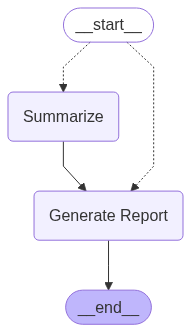

In [2]:
from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [2]:
from src.backend.vectordb import createVectorDBCollection, getLoader
from utils import Config

# createVectorDBCollection(collection_name='test',
#                         file_paths=[Config.DIR_DATA / 'uploaded_docs' / '10.docx'])

file_paths=[Config.DIR_DATA / 'uploaded_docs' / '10.docx',
            Config.DIR_DATA / 'uploaded_docs' / '11.pdf']

docs = []

for file_path in file_paths:

    loader = getLoader(file_path=file_path)
    
    for doc in loader:
        doc.metadata = {k: v for k, v in doc.metadata.items()}
        docs.append(doc)
        print(doc)

page_content='# DNA is conventionally portrayed as a passive register of genetic text, yet π-stacked base pairs also form a nanowire capable of transporting charges over tens—occasionally hundreds—of base pairs with distance-fall-off parameters (β ≈ 0.05 Å⁻¹) an order of magnitude shallower than through-space protein electron transfer. Any lesion that distorts stacking—8-oxo-guanine, abasic sites, cyclobutane dimers, interstrand cross-links, single- or double-strand breaks—acts as an electronic “open circuit.” Here we review how living systems exploit this property by equipping a surprisingly wide spectrum of DNA-processing enzymes with redox cofactors that function as built-in voltimeters. First, we summarize the physical chemistry of DNA charge transport (CT): coherent tunnelling versus multistep hopping, sequence and hydration effects, electron versus hole migration, and the ~+0.1–0.3 V window that places the DNA-bound 4Fe-4S²⁺/¹⁺ couple in perfect thermodynamic register with guanin